# Расчёт метрик сервиса доставки еды

Заказчик — сервис доставки еды «Всё.из.кафе». Нужно подготовить данные и визуализировать ключевые метрики для бизнеса. Необходимо разработать дашборд, который с разных сторон отразит состояние клиентской базы, и на основе этого дашборда составить аналитический отчёт.

## Описание данных
Данные сервиса состоят из нескольких таблиц.

Таблица `analytics_events` — журнал аналитических событий, или логи. В таблице хранятся данные о событиях в период с 30.04.2021 по 02.07.2021. Поля таблицы:
-    `visitor_uuid` — идентификатор посетителя. Это идентификатор, который система присваивает любому новому пользователю независимо от того, регистрировался ли он в продукте.
-    `user_id` — идентификатор зарегистрированного пользователя. Присваивается посетителю после создания учётной записи: ввода логина, пароля, адреса доставки и контактных данных.
-    `device_type` — тип платформы, с которой посетитель зашёл в продукт.
-    `city_id` — город, из которого посетитель зашёл в сервис.
-    `age` — возрастная группа пользователя. Она указывается при регистрации.
-    `source` — рекламный источник привлечения посетителя.
-    `first_date` — дата первого посещения продукта.
-    `visit_id` — уникальный идентификатор сессии.
-    `event` — название аналитического события.
-    `datetime` — дата и время события.
-    `log_date` — дата события.
-    `rest_id` — уникальный идентификатор сети, к которой принадлежит ресторан. Заполняется для заказов, карточек ресторанов и блюд.
-    `object_id` — уникальный идентификатор блюда. Заполняется для заказов и карточек блюд.
-    `listing_id` — уникальный идентификатор блюда в листинге. Листингом называется набор блюд, которые система рекомендует пользователю при просмотре страницы ресторана. Заполняется только для событий rest_page.
-    `position` — позиция блюда в листинге. Чем меньше номер, тем ближе блюдо к началу страницы. Заполняется только для событий rest_page.
-    `order_id` — уникальный идентификатор заказа.
-    `revenue` — выручка от заказа в рублях. Это та сумма, которую пользователь видит при оплате.
-    `delivery` — стоимость доставки в рублях.
-    `commission` — комиссия, которую «Всё.из.кафе» берёт с выручки ресторана.

В поле `event` таблицы также хранятся данные о нескольких типах аналитических событий:  
    `main_page` — посещение главной страницы приложения.  
    `authorization` — ввод логина и пароля, авторизация.  
    `rest_page` — просмотр страницы ресторана.  
    `object_page` — просмотр карточки блюда.  
    `order` — оплата заказа.

Таблица `advertisement_budgets` — рекламные затраты по дням и каналам привлечения. Поля таблицы:
-    `source` — рекламный источник.
-    `date` — дата рекламных затрат.
-    `budget` — дневной бюджет в рублях.

Таблица `partners` — справочник партнёрских сетей и их ресторанов. Поля таблицы:
-    `rest_id` — уникальный идентификатор сети, к которой принадлежит ресторан (одна сеть может быть представлена в нескольких городах).
-    `chain` — название сети, к которой принадлежит ресторан.
-    `type` — тип кухни.
-    `city_id` — город, в котором находится ресторан.
-    `commission` — комиссия в процентах, которую «Всё.из.кафе» берёт с выручки ресторана.

Таблица `dishes` — справочник блюд, доступных в партнёрских ресторанах. Поля таблицы:
-    `object_id` — уникальный идентификатор блюда.
-    `name` — название блюда.
-    `spicy` — логический признак острых блюд. 1 — блюдо острое.
-    `fish` — логический признак рыбных блюд. 1 — блюдо содержит морепродукты.
-    `meat` — логический признак мясных блюд. 1 — блюдо содержит мясо.
-    `rest_id` — уникальный идентификатор ресторана, из которого можно заказать блюдо.

Таблица `cities` — справочник населённых пунктов, в которых можно пользоваться продуктом. Поля таблицы:
-    `city_id` — уникальный идентификатор населённого пункта.
-    `city_name` — название населённого пункта.

Во всех задачах этого проекта считаем, что изучаем данные утром 1 июля 2021 года.

## Что нужно сделать

Задачи: подготовить QL-запросы в DataLens для визуализации метрик, создать визуализации в DataLens, на основе этих запросов создать дашборд, проанализировать результаты визуализаций и подготовить выводы в аналитической записке.

### 1. Подготовка QL-запросов для расчёта метрик

#### 1.1. Расчёт DAU

Рассчитаем ежедневное количество активных зарегистрированных клиентов (user_id) за май и июнь 2021 года в городе Саранске. Критерием активности клиента считаем размещение заказа, это позволит оценить эффективность вовлечения клиентов в ключевую бизнес-цель — совершение покупки.
Необходимо вывести следующие поля:
- log_date — дата события.
- DAU — количество активных зарегистрированных клиентов.  

Отсортируем результат по дате события в возрастающем порядке. Для проверки решения ограничим выгрузку первыми десятью строками.

In [ ]:
SELECT log_date,
       COUNT(DISTINCT user_id) AS DAU
FROM analytics_events AS events
JOIN cities ON events.city_id = cities.city_id
WHERE log_date BETWEEN '2021-05-01' AND '2021-06-30'
  AND city_name = 'Саранск'
  AND event = 'order'
GROUP BY log_date
ORDER BY log_date
LIMIT 10

log_date | dau
:------- | :-------:
2021-05-01 | 56
2021-05-02 | 36
2021-05-03 | 72
2021-05-04 | 85
2021-05-05 | 60
2021-05-06 | 52
2021-05-07 | 52
2021-05-08 | 52
2021-05-09 | 33
2021-05-10 | 35

#### 1.2. Расчёт Conversion Rate

Определим активность аудитории: как часто зарегистрированные пользователи переходят к размещению заказа, будет ли одинаковым этот показатель по дням или видны сезонные колебания в поведении пользователей. Для решения этой задачи рассчитаем конверсию зарегистрированных пользователей, которые посещают приложение, в активных клиентов. Конверсия должна быть рассчитана за каждый день в мае и июне 2021 года для клиентов из Саранска.
Необходимо вывести следующие поля:

- log_date — дата события.
- CR — значение конверсии.

Отсортируем результат по дню активности в возрастающем порядке. Для проверки решения ограничим выгрузку первыми десятью строками.

In [ ]:
SELECT log_date,
       ROUND((COUNT(DISTINCT user_id) FILTER (WHERE event = 'order'))/COUNT(DISTINCT user_id)::numeric, 2) AS CR
FROM analytics_events AS events
JOIN cities ON events.city_id = cities.city_id
WHERE log_date BETWEEN '2021-05-01' AND '2021-06-30'
  AND city_name = 'Саранск'
GROUP BY log_date
ORDER BY log_date
LIMIT 10

log_date | cr
:------- | :-------:
2021-05-01 | 0.43
2021-05-02 | 0.28
2021-05-03 | 0.41
2021-05-04 | 0.41
2021-05-05 | 0.32
2021-05-06 | 0.25
2021-05-07 | 0.28
2021-05-08 | 0.33
2021-05-09 | 0.28
2021-05-10 | 0.3

#### 1.3. Расчёт среднего чека

Рассчитаем средний чек активных клиентов в Саранске в мае и в июне.
Средний чек — это средний доход за одну транзакцию, то есть заказ. Мы анализируем средний чек сервиса доставки, а не ресторанов. Значит, необходимо вычислить его как среднее значение комиссии со всех заказов за месяц. Необходимо вывести следующие поля:

- "Месяц" — месяц события.
- "Количество заказов" — количество заказов за месяц.
- "Сумма комиссии" — сумма комиссии за месяц.
- "Средний чек" — средняя комиссия на одну транзакцию.

Сумму комиссии и среднего чека округлим до копеек (до двух знаков после запятой). Результат отсортируем по полю с месяцем в возрастающем порядке.

In [ ]:
WITH orders AS
    (SELECT *,
            revenue * commission AS commission_revenue
     FROM analytics_events
     JOIN cities ON analytics_events.city_id = cities.city_id
     WHERE revenue IS NOT NULL
         AND log_date BETWEEN '2021-05-01' AND '2021-06-30'
         AND city_name = 'Саранск')

SELECT DATE_TRUNC('month', log_date)::date AS "Месяц",
       COUNT(DISTINCT order_id) AS "Количество заказов",
       ROUND(SUM(commission_revenue)::numeric, 2) AS "Сумма комиссии",
       ROUND(SUM(commission_revenue)::numeric / COUNT(DISTINCT order_id), 2) "Средний чек"
FROM orders
GROUP BY "Месяц"
ORDER BY "Месяц"

Месяц | Количество заказов | Сумма комиссии | Средний чек
:------- | :-------: | :-------: | :-------:
2021-05-01 | 2111 | 286852 | 135.88
2021-06-01 | 2225 | 328539 | 147.66

#### 1.4. Расчёт LTV ресторанов

Определим три ресторана из Саранска с наибольшим LTV с начала мая до конца июня. LTV считаем как суммарную комиссию, которая была получена от заказов в ресторане за эти два месяца. Необходимо вывести следующие поля:

- rest_id — уникальный идентификатор сети, к которой принадлежит ресторан.
- "Название сети" — название сети, к которой принадлежит ресторан.
- "Тип кухни" — тип кухни ресторана.
- LTV — суммарная комиссия, которая была получена от заказов в ресторане за эти два месяца, округлённая до копеек.

Результат отсортируем по полю LTV в убывающем порядке.

In [ ]:
WITH orders AS
    (SELECT analytics_events.rest_id,
            analytics_events.city_id,
            revenue * commission AS commission_revenue
     FROM analytics_events
     JOIN cities ON analytics_events.city_id = cities.city_id
     WHERE revenue IS NOT NULL
         AND log_date BETWEEN '2021-05-01' AND '2021-06-30'
         AND city_name = 'Саранск')

SELECT orders.rest_id,
       chain AS "Название сети",
       type AS "Тип кухни",
       ROUND(SUM(commission_revenue)::numeric, 2) AS LTV
FROM orders
JOIN partners ON orders.rest_id = partners.rest_id AND orders.city_id = partners.city_id
GROUP BY orders.rest_id, chain, type
ORDER BY LTV DESC
LIMIT 3

rest_id | Название сети | Тип кухни | ltv
:------- | :------- | :-------: | -------:
2e2b2b9c458b42ce9da395ba9c247fdc | Гурманское Наслаждение | Ресторан | 170479
b94505e7efff41d2b2bf6bbb78fe71f2 | Гастрономический Шторм | Ресторан | 164508
42d14fe9fd254ba9b18ab4acd64d4f33 | 	Шоколадный Рай | Кондитерская | 61199.8

#### 1.5. Расчёт LTV ресторанов — самые популярные блюда

Проанализируем данные о ресторанах и их блюдах, чтобы определить вклад самых популярных блюд из двух ресторанов — «Гурманское Наслаждение» и «Гастрономический Шторм» — в общий показатель LTV. Для этого нужно выбрать пять блюд с максимальным LTV за весь рассматриваемый период, то есть за май — июнь, из этих двух ресторанов.
Для каждого блюда требуется вывести следующие поля:

- "Название сети" — название сети, к которой принадлежит ресторан.
- "Название блюда" — название блюда, которое оказалось популярным.
- spicy — логический признак острых блюд. 1 — блюдо острое.
- fish — логический признак рыбных блюд. 1 — блюдо содержит морепродукты.
- meat — логический признак мясных блюд. 1 — блюдо содержит мясо.
- LTV — суммарная комиссия, которая была получена от заказов блюда в ресторане за эти два месяца, округлённая до копеек.

Результаты отсортируем по значению LTV в порядке убывания. Для ознакомления ограничим выгрузку первыми пятью строками.

In [ ]:
WITH orders AS
    (SELECT analytics_events.rest_id,
            analytics_events.city_id,
            analytics_events.object_id,
            revenue * commission AS commission_revenue
     FROM analytics_events
     JOIN cities ON analytics_events.city_id = cities.city_id
     WHERE revenue IS NOT NULL
         AND log_date BETWEEN '2021-05-01' AND '2021-06-30'
         AND city_name = 'Саранск'), 

top_ltv_restaurants AS
    (SELECT orders.rest_id,
            chain,
            type,
            ROUND(SUM(commission_revenue)::numeric, 2) AS LTV
     FROM orders
     JOIN partners ON orders.rest_id = partners.rest_id AND orders.city_id = partners.city_id
     GROUP BY orders.rest_id, chain, type
     ORDER BY LTV DESC
     LIMIT 2),

SELECT chain AS "Название сети",
       dishes.name AS "Название блюда",
       spicy,
       fish,
       meat,
       ROUND(SUM(orders.commission_revenue)::numeric, 2) AS LTV
FROM orders
JOIN top_ltv_restaurants ON orders.rest_id = top_ltv_restaurants.rest_id
JOIN dishes ON orders.object_id = dishes.object_id AND top_ltv_restaurants.rest_id = dishes.rest_id
GROUP BY chain, dishes.name, spicy, fish, meat
ORDER BY LTV DESC
LIMIT 5

Название сети | Название блюда | spicy | fish | meat | ltv
:------- | :------- | :-------: | :-------: | :-------: | -------:
Гастрономический Шторм | brokkoli zapechennaja v duhovke s jajcami i travami | 0 | 1 | 1 | 41140.4
Гурманское Наслаждение | govjazhi shashliki v pesto iz kinzi | 0 | 1 | 1 | 36676.8
Гурманское Наслаждение | medaloni iz lososja | 0 | 1 | 1 | 14946.9
Гурманское Наслаждение | myasnye ezhiki | 0 | 0 | 1 | 14337.9
Гастрономический Шторм | teljatina s sousom iz belogo vina petrushki | 0 | 1 | 1 | 13981

#### 1.6. Расчёт Retention Rate

Рассчитаем показатель Retention Rate в первую неделю после регистрации для всех новых пользователей в Саранске.
Так как мы анализируем данные за май и июнь и для корректного расчёта недельного Retention Rate нужно, чтобы с момента первого посещения прошла хотя бы неделя, ограничим дату первого посещения продукта, выбрав промежуток с начала мая по 24 июня. Retention Rate будем считать по любой активности пользователей, а не только по факту размещения заказа.
В данных могут встречаться дубликаты по полю user_id, поэтому для корректного расчёта используем условие log_date >= first_date.
Необходимо вывести следующие поля:

-    day_since_install — срок жизни пользователя в днях.
-    retained_users — количество пользователей, которые вернулись в приложение в конкретный день.
-    retention_rate — коэффициент удержания для вернувшихся пользователей по отношению к общему числу пользователей, которые установили приложение.

Результаты отсортируем по полю day_since_install в порядке возрастания.

In [ ]:
WITH new_users AS
    (SELECT DISTINCT first_date,
                     user_id
     FROM analytics_events
     JOIN cities ON analytics_events.city_id = cities.city_id
     WHERE first_date BETWEEN '2021-05-01' AND '2021-06-24'
         AND city_name = 'Саранск'),

active_users AS
    (SELECT DISTINCT log_date,
                     user_id
     FROM analytics_events
     JOIN cities ON analytics_events.city_id = cities.city_id
     WHERE log_date BETWEEN '2021-05-01' AND '2021-06-30'
         AND city_name = 'Саранск'),

daily_retention AS
  (SELECT new_users.user_id,
          first_date,
          log_date,        
          log_date - first_date AS day_since_install
   FROM new_users
   JOIN active_users ON new_users.user_id = active_users.user_id AND log_date >= first_date)

SELECT day_since_install,
       COUNT(DISTINCT user_id) AS retained_users,
       ROUND(1.0 * COUNT(DISTINCT user_id) / MAX(COUNT(DISTINCT user_id)) OVER (), 2) AS retention_rate
FROM daily_retention
WHERE day_since_install < 8
GROUP BY day_since_install
ORDER BY day_since_install

day_since_install | retained_users | retention_rate
:-------: | :-------: | -------:
0 | 5572 | 1
1 | 768 | 0.14
2 | 419 | 0.08
3 | 283 | 0.05
4 | 251 | 0.05
5 | 207 | 0.04
6 | 205 | 0.04
7 | 205 | 0.04

#### 1.7. Сравнение Retention Rate по месяцам

Разделим пользователей на две когорты по месяцу первого посещения продукта. Необходимо вывести следующие поля:

- "Месяц" — месяц первого посещения продукта.
- day_since_install — срок жизни пользователя в днях.
- retained_users — количество пользователей, которые вернулись в приложение в конкретный день.
- retention_rate — коэффициент удержания для вернувшихся пользователей по отношению к общему числу пользователей, которые установили приложение в день установки.

Результаты отсортируем по полям "Месяц" и day_since_install в порядке возрастания.

In [ ]:
WITH new_users AS
    (SELECT DISTINCT first_date,
                     user_id
     FROM analytics_events
     JOIN cities ON analytics_events.city_id = cities.city_id
     WHERE first_date BETWEEN '2021-05-01' AND '2021-06-24'
         AND city_name = 'Саранск'),

active_users AS
    (SELECT DISTINCT log_date,
                     user_id
     FROM analytics_events
     JOIN cities ON analytics_events.city_id = cities.city_id
     WHERE log_date BETWEEN '2021-05-01' AND '2021-06-30'
         AND city_name = 'Саранск'),

daily_retention AS
    (SELECT new_users.user_id,
            first_date,
            log_date::date - first_date::date AS day_since_install
     FROM new_users
     JOIN active_users ON new_users.user_id = active_users.user_id
     AND log_date >= first_date)

SELECT DATE_TRUNC('month', first_date)::date AS "Месяц",
        day_since_install,
        COUNT(DISTINCT user_id) AS retained_users,
        ROUND(1.0 * COUNT(DISTINCT user_id) / MAX(COUNT(DISTINCT user_id)) OVER (PARTITION BY DATE_TRUNC('month', first_date)::date), 2) AS retention_rate
FROM daily_retention
WHERE day_since_install < 8
GROUP BY "Месяц", day_since_install
ORDER BY "Месяц", day_since_install

Месяц | day_since_install | retained_users | retention_rate
:-------: | :-------: | :-------: | -------:
2021-05-01 | 0 | 3069 | 1
2021-05-01 | 1 | 443 | 0.14
2021-05-01 | 2 | 223 | 0.07
2021-05-01 | 3 | 144 | 0.05
2021-05-01 | 4 | 142 | 0.05
2021-05-01 | 5 | 122 | 0.04
2021-05-01 | 6 | 120 | 0.04
2021-05-01 | 7 | 140 | 0.05
2021-06-01 | 0 | 2576 | 1
2021-06-01 | 1 | 328 | 0.13
2021-06-01 | 2 | 196 | 0.08
2021-06-01 | 3 | 140 | 0.05
2021-06-01 | 4 | 109 | 0.04
2021-06-01 | 5 | 86 |0.03
2021-06-01 | 6 | 85 | 0.03
2021-06-01 | 7 | 65 | 0.03

### 2. Построение дашборда в DataLens

С использованием подготовленных выше запросов создадим семь чартов и разработаем дашборд «Ключевые бизнес-метрики в Саранске (май — июнь 2021)»: 

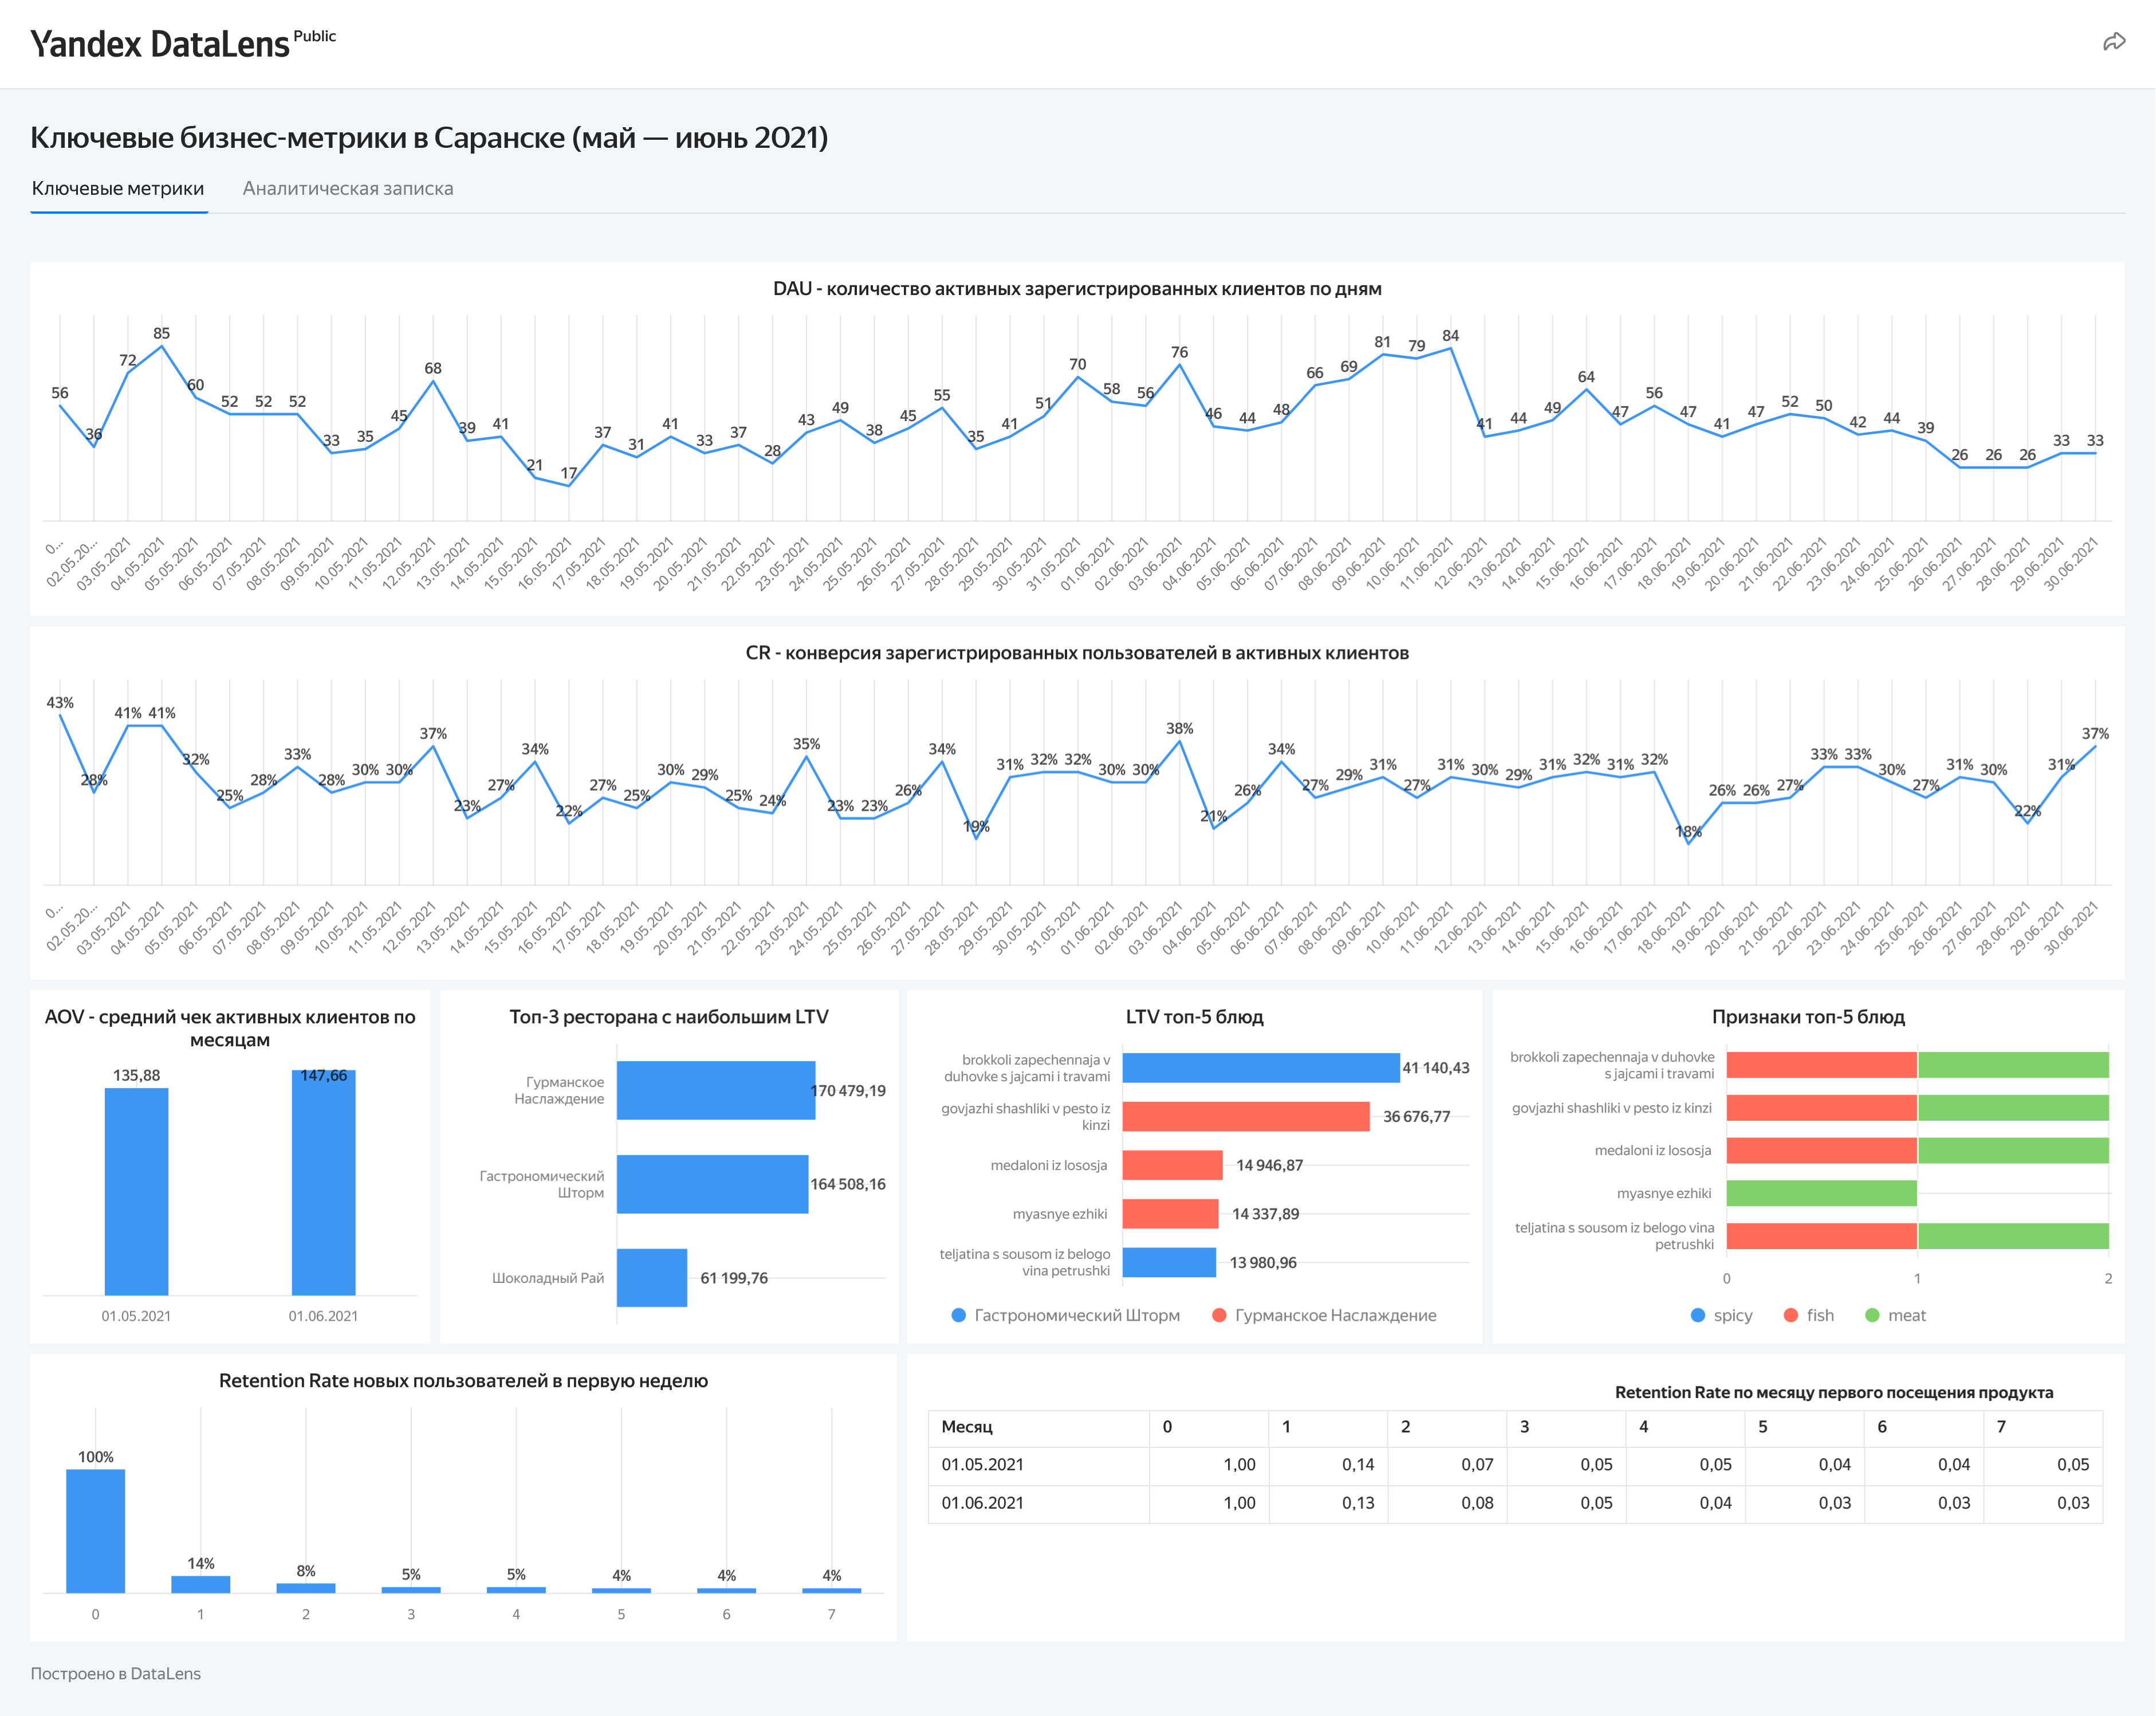

Подготовлена аналитическая записка с обзором ключевых метрик сервиса доставки еды «Всё.из.кафе» в Саранске за период с 1 мая по 30 июня 2021 года:

1. DAU (активные пользователи за день): наблюдается существенный разброс количества активных пользователей (от 17 до 85) и зависимость показателя от дня недели: рост в будни и падение в выходные. Также видно снижение DAU примерно с середины июня. Пиковые значения приходятся на 4 мая (85), первый рабочий день после праздников, и на 11 июня (84), предпраздничный день. Минимальное значение зафиксировано 16 мая (17), выходной день. Можно предположить, что сервис используется в основном для заказа еды в офис, это объясняет спад количества активных пользователей в выходные и рост в предпраздничные и послепраздничные дни. Снижение показателя в июне может быть связано с началом периода отпусков, дачного сезона и окончанием учебного года и отъездом студентов.


2. Conversion Rate (коэффициент конверсии): наблюдается существенный разброс коэффициента конверсии (от 18% до 43%), в июне значение показателя более стабильно (меньше пиков и провалов), что может быть связано с началом летнего периода и сезона отпусков / дач. Видна зависимость коэффициента конверсии от дня недели: снижение показателя к четвергу-пятнице и рост с субботы-воскресенья. Это может быть связано с тем, что в конце рабочей недели пользователи выбирают другие варианты (кафе, рестораны) или планируют осуществить заказ в выходные. Высокое значение CR наблюдается в начале мая, в праздничные и выходные дни с 1 по 3 мая, но при этом следующие праздники с 8 по 10 мая и с 12 по 14 июня прошли без подобных всплесков, в связи с чем можно предположить отсутствие зависимости CR от праздников.  


3. Средний чек: наблюдается рост показателя в июне (147,66 по сравнению с 135,88 в мае). Это может быть связано с увеличением размера заказов в летний период, с увеличением комиссии ресторанов, с увеличением числа ресторанов, работающих с сервисом, а также с увеличением доли платежеспособных пользователей (например, из-за отъезда студентов).  


4. Retention Rate (коэффициент удержания пользователей): наблюдается сильный отток клиентов на следующий день после регистрации в приложении: только 14% пользователей возвращаются в сервис; начиная с 3-5 дня коэффициент стабилизируется на уровне 4-5%, спустя 7 дней после регистрации процент активных пользователей составляет 4%. Это может быть связано с использованием пользователями сервиса «на 1 раз» из-за недостаточного ассортимента или высокого уровня цен, также могут быть какие-то трудности при оформлении или оплате заказа. В июне коэффициент удержания пользователей ниже, чем в мае: на следующий день возвращается на 1% меньше, спустя 7 дней процент активных пользователей ниже на 2%. Это может быть связано с сезонным снижением потребности: период отпусков, дачный сезон, отъезд студентов.  


5. Топ-3 ресторанов по LTV: наибольшая суммарная комиссия была получена с двух ресторанов: Гурманское Наслаждение (170479) и Гастрономический Шторм (164508), а также с кондитерской Шоколадный Рай (61200). Видно, что ресторанный сегмент доминирует с существенным превышением LTV. Наиболее популярные пять блюд – это полноценные блюда, а не десерты. Самим популярными с большим отрывом LTV являются «Брокколи, запечённая с яйцами и травами» и «Говяжьи шашлыки в песто из кинзы». Все блюда из топ-5 не относятся к категории острых, что может говорить о низкой популярности острых блюд или их малом ассортименте в меню. Стоит отметить наличие ошибок в классификации блюд: блюдо из брокколи с яйцом отмечено как мясное и рыбное блюдо, медальоны из лосося содержат отметку о наличии мяса, говяжьи шашлыки и телятина отмечены не только как мясные, но и как рыбные блюда. Такие ошибки могут приводить к некорректным результатам поиска блюд по данным критериям и в результате снижать интерес к дальнейшим заказам. 


6. Рекомендации:
-    С учетом большого оттока пользователей на следующий день после регистрации можно рекомендовать проведение акций для увеличения повторных заказов, например, скидка или бесплатная доставка на повторный заказ в течение 3-5 дней, уведомление со специальным предложением спустя 7 дней. Также можно дополнительно проанализировать необходимость доработки приложения в части удобства оформления или оплаты заказа.
-    Для повышения коэффициента конверсии в конце рабочей недели можно предложить запустить проведение акций для оформления заказов в будни, например, предложить скидку на предзаказ на выходные.
-    Для привлечения пользователей в летний период ввести сезонные предложения.
-    Провести дополнительный анализ влияния внешних факторов на ключевые показатели: погоды, праздников, технических сбоев, а также рекламных кампаний.

Дашборд доступен по ссылке [ссылке](https://datalens.yandex/11gws03sl64al)